In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import pandas as pd
import numpy as np
import os

2026-04-19 14:12:43.974096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776607964.224792      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776607964.293904      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776607964.830984      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776607964.831021      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776607964.831023      55 computation_placer.cc:177] computation placer alr

In [3]:
strategy = tf.distribute.MirroredStrategy()

print("Number of GPUs:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs: 2


I0000 00:00:1776608100.582830      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776608100.588670      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.


In [6]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])
    return model

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

def build_mobilenet():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False  # Freeze

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=out)

In [8]:
from tensorflow.keras.applications import ResNet50

def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=out)

In [9]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=out)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [11]:
def train_model(build_fn, name):
    
    with strategy.scope():
        model = build_fn()

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=8,
        callbacks=[early_stop],
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"{name} Best Val Accuracy:", val_acc)

    return model, val_acc ,history

In [14]:
results = {}

cnn_model, acc_cnn, history_cnn = train_model(build_cnn, "CNN")
results["CNN"] = (cnn_model, acc_cnn)

mobilenet_model, acc_mob, history_mobilenet = train_model(build_mobilenet, "MobileNet")
results["MobileNet"] = (mobilenet_model, acc_mob)

resnet_model, acc_res, history_resnet = train_model(build_resnet, "ResNet")
results["ResNet"] = (resnet_model, acc_res)

efficient_model, acc_eff, history_efficientnet = train_model(build_efficientnet, "EfficientNet")
results["EfficientNet"] = (efficient_model, acc_eff)

Epoch 1/8
INFO:tensorflow:Collective all_reduce tensors: 12 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
119/119 ━━━━━━━━━━━━━━━━━━━━ 78s 637ms/step - accuracy: 0.6676 - loss: 5.2174 - val_accuracy: 0.4677 - val_loss: 4.6469
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 626ms/step - accuracy: 0.7732 - loss: 2.9496 - val_accuracy: 0.4614 - val_loss: 7.1164
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 626ms/step - accuracy: 0.7954 - loss: 2.6173 - val_accuracy: 0.5280 - val_loss: 4.4345
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 634ms/step - accuracy: 0.7787 - loss: 2.3884 - val_accuracy: 0.6646 - val_loss: 2.9132
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 629ms/step - accuracy: 0.7941 - loss: 2.1466 - val_accuracy: 0.8169 - val_loss: 1.9860
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 74s 623ms/step - accuracy: 0.8213 - loss: 1.8848 - val_accuracy: 0.8656 - val_loss: 1.7292
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 74s 625ms/step - acc

E0000 00:00:1776611233.287648      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


119/119 ━━━━━━━━━━━━━━━━━━━━ 90s 669ms/step - accuracy: 0.4901 - loss: 3.0011 - val_accuracy: 0.5407 - val_loss: 2.6639
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 73s 610ms/step - accuracy: 0.5342 - loss: 2.6211 - val_accuracy: 0.5344 - val_loss: 2.3815
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 625ms/step - accuracy: 0.5273 - loss: 2.3442 - val_accuracy: 0.5206 - val_loss: 2.1546
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 74s 619ms/step - accuracy: 0.5542 - loss: 2.1129 - val_accuracy: 0.5280 - val_loss: 1.9665
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 634ms/step - accuracy: 0.5255 - loss: 1.9421 - val_accuracy: 0.5238 - val_loss: 1.8122
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 635ms/step - accuracy: 0.5543 - loss: 1.7889 - val_accuracy: 0.5185 - val_loss: 1.6844
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 627ms/step - accuracy: 0.5443 - loss: 1.6663 - val_accuracy: 0.5238 - val_loss: 1.5761
Epoch 8/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 74s 623ms/step - accuracy: 0.5349 - loss: 1.5603 - val_accura

In [15]:
best_name = max(results, key=lambda x: results[x][1])
best_model = results[best_name][0]

print("Best Model:", best_name)

Best Model: MobileNet


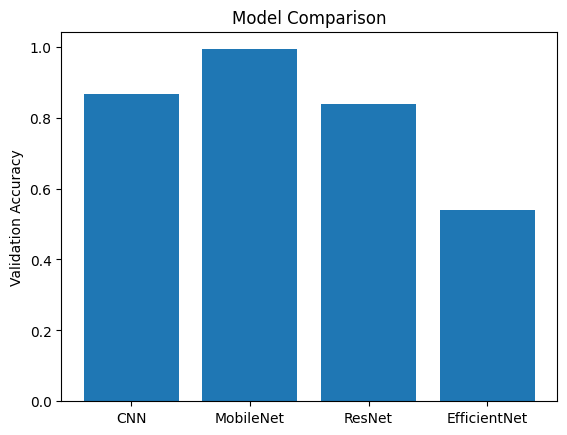

In [16]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = [results[m][1] for m in models]
#Itz Ary99Pk
plt.bar(models, accuracies)
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.show()

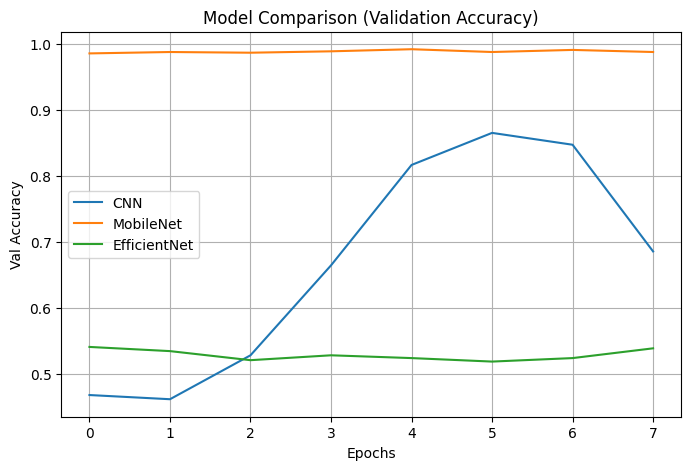

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.plot(history_mobilenet.history['val_accuracy'], label='MobileNet')
plt.plot(history_efficientnet.history['val_accuracy'], label='EfficientNet')

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid()

plt.show()

In [31]:
import pandas as pd
import os
import numpy as np
from tensorflow.keras.preprocessing import image

df = pd.read_csv("/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test_solution_01.csv")

ids = df['ID'].tolist() 

In [32]:
test_dir = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"

In [34]:
import numpy as np

images = []
valid_ids = []

for img_name in ids:
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0

    images.append(img_array)
    valid_ids.append(img_name)

# Convert to array
images = np.array(images)

# 🔥 SINGLE PREDICTION CALL
preds = best_model.predict(images)

# Convert to labels
preds = (preds > 0.5).astype(int).reshape(-1)

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step


In [42]:
# reverse mapping
labels_map = {0: 'chihuahua', 1: 'muffin'}

preds = (preds > 0.5).astype(int).reshape(-1)

pred_labels = [labels_map[p] for p in preds]

In [50]:
submission = pd.DataFrame({
    "ID": valid_ids,
    "Label": pred_labels
})

submission.to_csv("submission.csv", index=False)

In [51]:
print(train_data.class_indices)

{'chihuahua': 0, 'muffin': 1}


In [54]:
submission.head(20)
#Itz Ary99Pk

,ID,Label
0,img_0_0.jpg,muffin
1,img_0_10.jpg,muffin
2,img_0_1000.jpg,muffin
3,img_0_1037.jpg,muffin
4,img_0_105.jpg,muffin
5,img_0_1050.jpg,muffin
6,img_0_1051.jpg,muffin
7,img_0_1061.jpg,muffin
8,img_0_1063.jpg,muffin
9,img_0_1071.jpg,chihuahua
